# MOSAIC -- Global Optimization Phase (clustering, $\alpha=1$, $\beta=0$)

Reads `exp_global.py`'s output and plots the clustering-quality metrics
(see `src/global_opt.py`): pairwise F1 (network-wide micro-average) and ARI
(macro-averaged over mechanisms), for MOSAIC (W-2/W-3) against two
baselines -- the local-IDM "no update" ablation and the naive MLE
point-estimate baseline (oracle $k$, see `cluster_mle_gaps`) -- across the
swept ESS ($S$) hyperparameter, faceted by $\alpha$.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa


In [20]:
# Read config file
config = load_config("conf_global.yaml")

# Results folder: a single one for the whole hyperparameter grid (see
# exp_global.py) -- each row of df_tot.csv already carries its own
# n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

df_tot = pd.read_csv(res_path / "df_tot.csv")
df_tot.head()


,n_clients,ess,prob_shift,alpha,size,rep,mos_w2_precision,mos_w2_recall,mos_w2_f1,mos_w2_ari,...,noupdate_ari,noupdate_ami,noupdate_n_clusters_mean,mle_precision,mle_recall,mle_f1,mle_ari,mle_ami,mle_n_clusters_mean,n_clusters_true_mean
0,10,1,0.5,0.1,200,11,0.341969,0.500000,0.406154,0.040748,...,0.003241,0.019254,3.7,0.379747,0.227273,0.284360,0.044820,0.072497,5.5,5.5
1,10,1,0.5,0.1,200,10,0.204762,0.270440,0.233062,-0.040974,...,-0.010502,-0.002423,4.0,0.580952,0.383648,0.462121,0.141864,0.167500,5.0,5.0
2,10,1,0.5,0.1,200,9,0.228700,0.447368,0.302671,-0.003190,...,-0.027977,-0.046923,4.1,0.517241,0.394737,0.447761,0.100978,0.078785,6.0,6.0
3,10,1,0.5,0.1,200,13,0.254902,0.361111,0.298851,-0.032276,...,-0.018831,-0.012640,3.7,0.402174,0.256944,0.313559,0.013978,-0.002007,5.3,5.3
4,10,1,0.5,0.1,200,12,0.218750,0.222222,0.220472,-0.003496,...,0.042809,0.078008,4.1,0.463415,0.301587,0.365385,0.114773,0.152017,5.6,5.6


## Aggregation

Every numeric column already lives at the (hyperparameter combination x
repetition) level; group by every grid hyperparameter (not just the ones
that vary in the current `conf_global.yaml`, so this still works if the
grid is extended later) and take mean/std across repetitions.


In [21]:
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
metric_cols = [c for c in df_tot.columns if c not in group_cols + ["rep"]]

agg = df_tot.groupby(group_cols)[metric_cols].agg(["mean", "std"])
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
df_mean = agg.reset_index()
df_mean.head()


,n_clients,ess,prob_shift,alpha,size,mos_w2_precision_mean,mos_w2_precision_std,mos_w2_recall_mean,mos_w2_recall_std,mos_w2_f1_mean,...,mle_f1_mean,mle_f1_std,mle_ari_mean,mle_ari_std,mle_ami_mean,mle_ami_std,mle_n_clusters_mean_mean,mle_n_clusters_mean_std,n_clusters_true_mean_mean,n_clusters_true_mean_std
0,10,1,0.5,0.1,200,0.257589,0.076523,0.431545,0.109089,0.319394,...,0.338972,0.076631,0.060785,0.080265,0.064254,0.095338,5.615,0.382891,5.615,0.382891
1,10,10,0.5,0.1,200,0.272427,0.063905,0.584821,0.098050,0.369945,...,0.338972,0.076631,0.060785,0.080265,0.064254,0.095338,5.615,0.382891,5.615,0.382891
2,10,20,0.5,0.1,200,0.289818,0.059075,0.654923,0.080717,0.400111,...,0.338972,0.076631,0.060785,0.080265,0.064254,0.095338,5.615,0.382891,5.615,0.382891
3,10,50,0.5,0.1,200,0.343402,0.057229,0.858937,0.054742,0.488801,...,0.338972,0.076631,0.060785,0.080265,0.064254,0.095338,5.615,0.382891,5.615,0.382891
4,10,100,0.5,0.1,200,0.349516,0.049236,0.990808,0.016927,0.515122,...,0.338972,0.076631,0.060785,0.080265,0.064254,0.095338,5.615,0.382891,5.615,0.382891


In [22]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        "figure.figsize": [7, 4],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "lines.linewidth": 1.0,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "text.usetex": True,
    }
)


## Methods and facets

Rows/cols are collapsed to a single facet on $\alpha$ (the only
hyperparameter besides $S$ that this grid actually sweeps: `n_clients` and
`prob_shift` are single fixed values here, unlike the local phase's grid).
$S$ (ESS) is the x-axis, log-scaled, since it is expected to drive the
largest differences (the clustering step currently relies on HARD credal-set
intersection -- see `cap6_extract.tex`, "Practical Considerations" -- so a
wider/narrower credal set directly changes how often two clients' sets
overlap).


In [23]:
METHODS = ("mos_w2", "mos_w3", "noupdate", "mle")
method_colors = {
    "mos_w2": "#4fc685",
    "mos_w3": "#9a97f4",
    "noupdate": "#fc9167",
    "mle": "#888888",
}
method_labels = {
    "mos_w2": "MOSAIC (W-2: intersection)",
    "mos_w3": "MOSAIC (W-3: JSD-based)",
    "noupdate": "No update (local IDM)",
    "mle": "MLE point-estimate (oracle $k$)",
}

alpha_vals = sorted(df_mean["alpha"].unique())
print(f"Facet: {len(alpha_vals)} alpha value(s) x {len(METHODS)} methods, S on the x-axis.")


def plot_metric(metric, ylabel, ylim=None, hline=None):
    fig, axes = plt.subplots(
        1,
        len(alpha_vals),
        figsize=(4.5 * len(alpha_vals), 3.3),
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    for j, a in enumerate(alpha_vals):
        ax = axes[0][j]
        sub = df_mean[df_mean["alpha"] == a].sort_values("ess")
        if hline is not None:
            ax.axhline(hline, color="gray", linewidth=0.7, linestyle=":")
        for m in METHODS:
            mean = sub[f"{m}_{metric}_mean"]
            std = sub[f"{m}_{metric}_std"]
            ax.fill_between(sub["ess"], mean - std, mean + std, color=method_colors[m], alpha=0.15)
            ax.plot(sub["ess"], mean, color=method_colors[m], marker="o", label=method_labels[m])
        ax.set_xscale("log")
        ax.set_title(fr"$\alpha={a}$", fontsize=10)
        ax.set_xlabel("$S$ (ESS)")
        if ylim:
            ax.set_ylim(*ylim)
    axes[0][0].set_ylabel(ylabel)
    axes[0][-1].legend(loc="best", fontsize=7)
    plt.tight_layout()
    return fig


Facet: 1 alpha value(s) x 4 methods, S on the x-axis.


## Grafico 1: pairwise F1 (network-wide, micro-averaged)

Every client pair, of every mechanism $(X, \pi_X)$, in one repetition is
pooled into a single confusion matrix before computing precision/recall/F1
(see `src/global_opt.py::pairwise_confusion`) -- the natural aggregation
here, since P/R/F1 are properties of individual client pairs and every
mechanism contributes the same number of pairs. Band is mean $\pm$ 1 std
**across repetitions**.


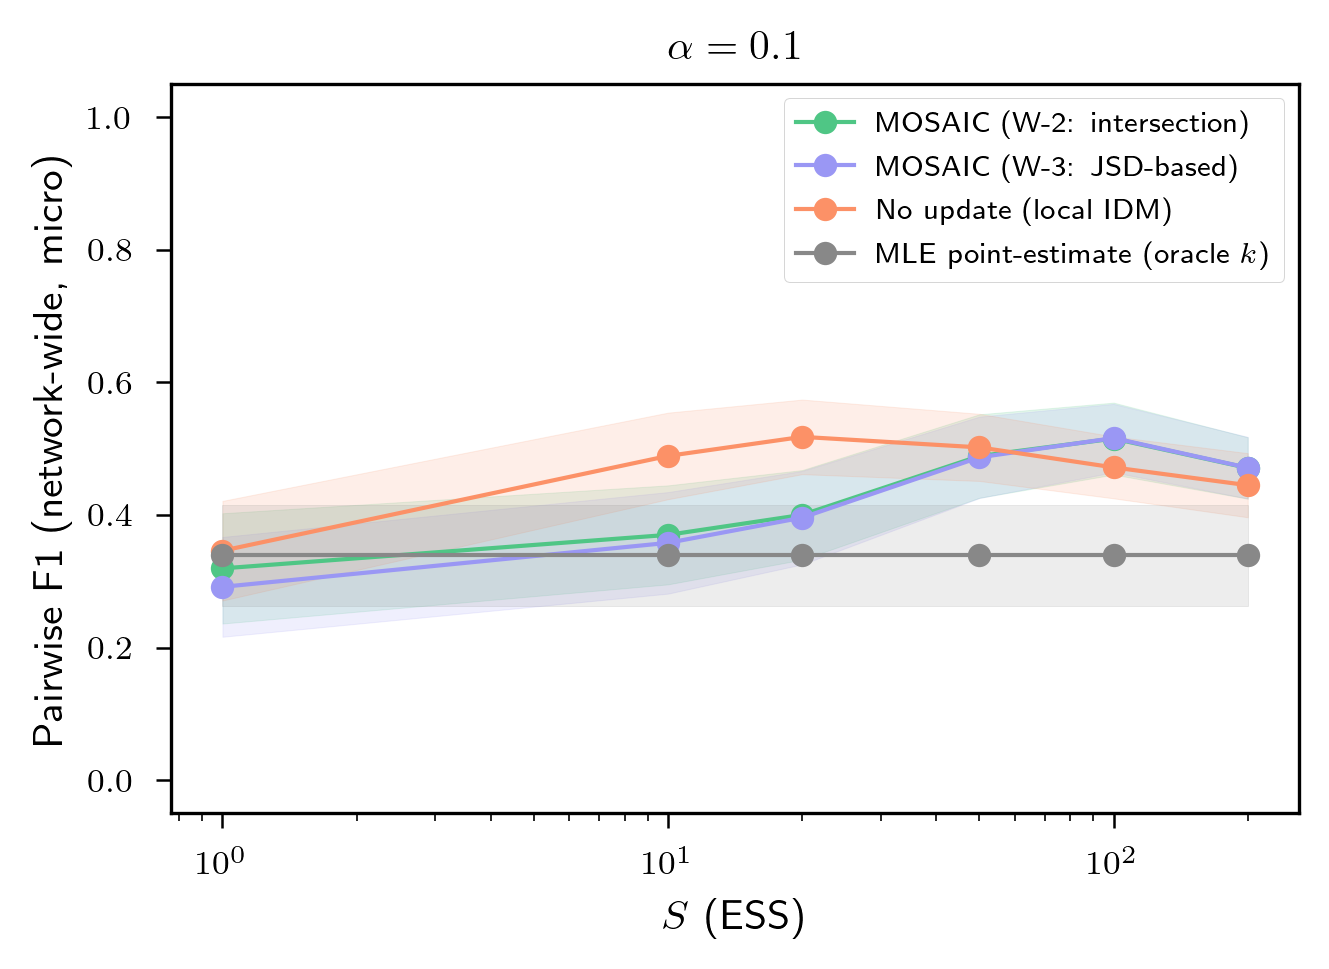

In [24]:
fig = plot_metric("f1", "Pairwise F1 (network-wide, micro)", ylim=(-0.05, 1.05))
plt.show()
fig.savefig(f"{res_path}_f1.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 2: Adjusted Rand Index (macro-averaged over mechanisms)

Unlike F1, ARI compares two *partitions* of the same client set, so it
cannot be pooled across mechanisms (each mechanism has its own true
partition): computed per mechanism, then macro-averaged (plain mean) across
the network's mechanisms (see `src/global_opt.py::ari_ami`), then, as
always, mean $\pm$ std across repetitions.


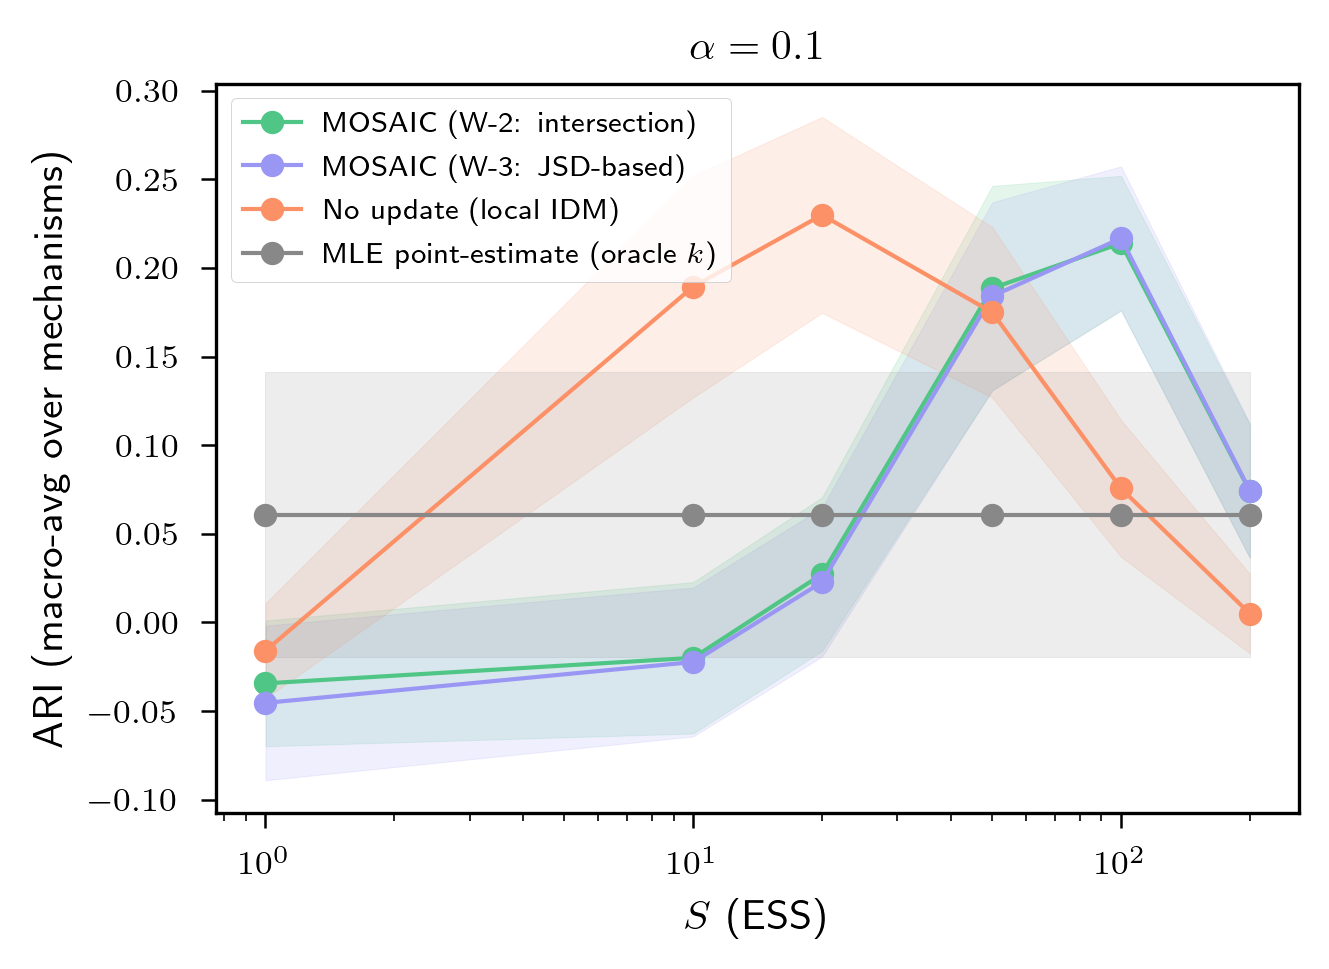

In [25]:
fig = plot_metric("ari", "ARI (macro-avg over mechanisms)")
plt.show()
fig.savefig(f"{res_path}_ari.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 3: mean number of clusters found (diagnostic)

Not a headline accuracy metric, but a useful diagnostic for *why* F1/ARI
move the way they do: how many clusters each method finds, network-wide,
versus the true mean cluster count (dashed). `mle`'s baseline is handed the
true cluster count as an oracle (`cluster_mle_gaps`, see `src/global_opt.py`
-- deliberately conservative, i.e. an advantage MOSAIC does NOT get), so its
curve sits exactly on top of "True" by construction; it is shown mainly as
a visual anchor for the other three methods, which get no such help.


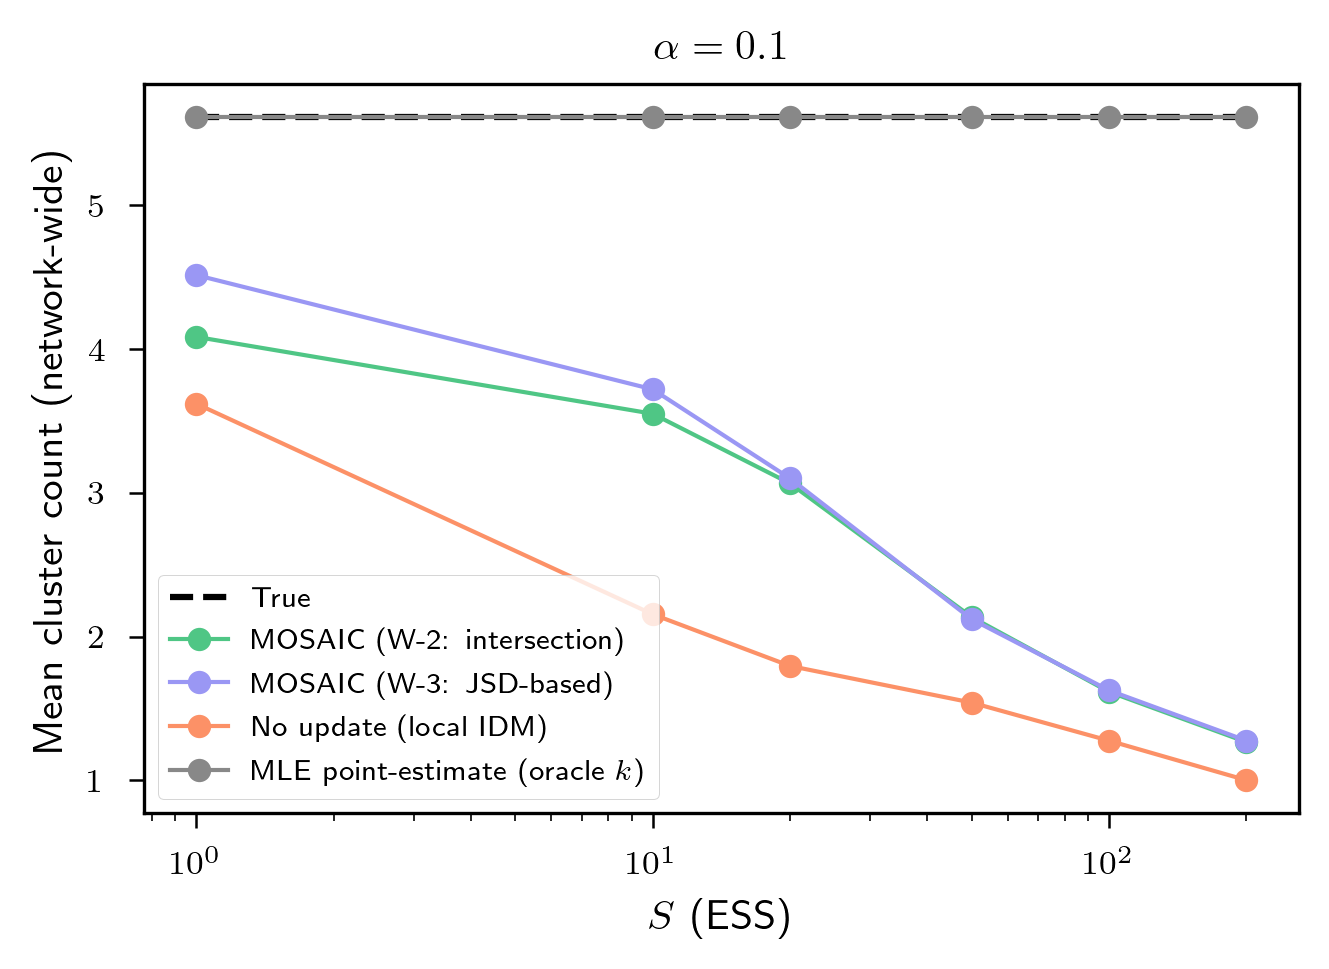

In [26]:
fig, axes = plt.subplots(
    1, len(alpha_vals), figsize=(4.5 * len(alpha_vals), 3.3), squeeze=False, sharex=True, sharey=True
)
for j, a in enumerate(alpha_vals):
    ax = axes[0][j]
    sub = df_mean[df_mean["alpha"] == a].sort_values("ess")
    ax.plot(sub["ess"], sub["n_clusters_true_mean_mean"], "k--", label="True", linewidth=1.5)
    for m in METHODS:
        ax.plot(sub["ess"], sub[f"{m}_n_clusters_mean_mean"], color=method_colors[m], marker="o", label=method_labels[m])
    ax.set_xscale("log")
    ax.set_title(fr"$\alpha={a}$", fontsize=10)
    ax.set_xlabel("$S$ (ESS)")
axes[0][0].set_ylabel("Mean cluster count (network-wide)")
axes[0][-1].legend(fontsize=7)
plt.tight_layout()
plt.show()
fig.savefig(f"{res_path}_nclusters.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Loading a saved model (`results_global/models/<task_id>.pkl`)

Reference example for reading back a model saved by `exp_global.py`. Unlike
`exp.py` (client 0 only), every client's MOSAIC-updated credal set is
archived, so keys are prefixed `client{e}_...`. **Always go through
`lookup_cpt_row`**, never `cpt.topandas()` or a hand-rolled row index (see
`snapshot_cpts`/`lookup_cpt_row` in `src/utils.py`).


In [27]:
import pickle
from src.utils import lookup_cpt_row

models_dir = res_path / "models"
model_files = sorted(models_dir.glob("*.pkl"))
print(f"{len(model_files)} saved models found in {models_dir}")

# The filename IS the task_id (n_clients, ess, prob_shift, alpha, size, rep).
model_path = model_files[0]
print("Example task_id (n_clients, ess, prob_shift, alpha, size, rep):", model_path.stem)

with open(model_path, "rb") as f:
    model = pickle.load(f)
print("Available model kinds (first 10 of", len(model), "):", sorted(model.keys())[:10])

# Read P(Cancer | Pollution, Smoker) from client 3's MOSAIC-updated credal
# set (weighting=3, lower bound), for one specific parent configuration.
entry = model["client3_mos_w3_min"]["C"]
print("\nC's parent configurations (row order):", entry["parents"])
print("C's own category labels (column order):", entry["labels"])

row = lookup_cpt_row(entry, parents={"P": "low", "S": "True"})
print(
    "\nP(C | P=low, S=True)  [client 3, MOSAIC w3, lower bound] =",
    dict(zip(entry["labels"], row)),
)

# A root variable (no parents) is read the same way, with parents=None.
entry_p = model["client3_bn_mle"]["P"]
print(
    "P(Pollution)  [client 3's exact MLE] =",
    dict(zip(entry_p["labels"], lookup_cpt_row(entry_p))),
)


120 saved models found in results_global/models
Example task_id (n_clients, ess, prob_shift, alpha, size, rep): 10_100_0.5_0.1_200_0
Available model kinds (first 10 of 70 ): ['client0_bn_mle', 'client0_idm_max', 'client0_idm_min', 'client0_mos_w2_max', 'client0_mos_w2_min', 'client0_mos_w3_max', 'client0_mos_w3_min', 'client1_bn_mle', 'client1_idm_max', 'client1_idm_min']

C's parent configurations (row order): [{'P': 'low', 'S': 'True'}, {'P': 'high', 'S': 'True'}, {'P': 'low', 'S': 'False'}, {'P': 'high', 'S': 'False'}]
C's own category labels (column order): ['True', 'False']

P(C | P=low, S=True)  [client 3, MOSAIC w3, lower bound] = {'True': np.float64(0.0044769938714947465), 'False': np.float64(0.278126453283579)}
P(Pollution)  [client 3's exact MLE] = {'low': np.float64(0.895), 'high': np.float64(0.105)}
